# Body assessment (men and women)

Sex is read from the workbook's Measurements sheet for the analysis date and selects the sex-specific parameters
(Navy formula, Wilks, lift factors, FRIEND norms, size upper reference, proportion ideals). The female assessment has extra
limitations (no frame-based size reference, no girth maxima, only two proportion ratios); see the workbook's Read me.

This notebook is a second implementation, in Python, of the same rules as `body_assessment.xlsx` / `.ods`. It catches
implementation errors in either (the two must agree), not errors in the rules themselves.
It holds **no data and no constants of its own**: measurements come from the workbook's *Measurements* sheet
and every coefficient from its *Parameters* sheet, so the two cannot silently drift apart. Its additions are
plots, the measurement history, and a final cell that checks its numbers against the workbook's *Report* sheet.

Edit measurements and parameters in the workbook, save it, then re-run this notebook.
Reading `.ods` requires `odfpy` (`pip install odfpy`).

In [1]:
# Configuration
WORKBOOK = "body_assessment.xlsx"   # or "body_assessment.ods"
ANALYSIS_DATE = None                 # None = latest dated column, or e.g. "2026-09-23"


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

engine = "odf" if WORKBOOK.endswith(".ods") else None

# ---- Measurements: rows = site keys, columns = dates
meas = pd.read_excel(WORKBOOK, sheet_name="Measurements", engine=engine)
meas = meas[meas["key"].notna() & (meas["key"] != "notes")].set_index("key")
date_cols = [c for c in meas.columns if isinstance(c, (pd.Timestamp,)) or hasattr(c, "year")]
if not date_cols:
    raise ValueError("No dated columns found in Measurements row 1.")
history = meas[date_cols].apply(pd.to_numeric, errors="coerce")
history.columns = pd.to_datetime(history.columns)
history = history.loc[:, history.notna().any()].sort_index(axis=1)

# ---- Parameters: three tables, located by their header rows
praw = pd.read_excel(WORKBOOK, sheet_name="Parameters", header=None, engine=engine)

def block(first_header, second_header):
    starts = praw.index[(praw[0] == first_header) & (praw[1] == second_header)]
    if len(starts) != 1:
        raise ValueError(f"Parameters table with header {first_header!r}/{second_header!r} not found exactly once.")
    s = starts[0]
    cols = [c for c in praw.loc[s] if isinstance(c, str)]
    rows = []
    for i in range(s + 1, len(praw)):
        if pd.isna(praw.loc[i, 0]):
            break
        rows.append(list(praw.loc[i, : len(cols) - 1]))
    return pd.DataFrame(rows, columns=cols)

P = block("key", "value").set_index("key")["value"].astype(float).to_dict()

# Sex: read as text from the analysis-date column; it selects the sex-specific parameters
text_vals = meas[date_cols].copy()
text_vals.columns = pd.to_datetime(text_vals.columns)
_date0 = history.columns[-1] if ANALYSIS_DATE is None else pd.Timestamp(ANALYSIS_DATE)
SEX = str(text_vals.at["sex", _date0]).strip().lower()
if SEX not in ("male", "female"):
    raise ValueError(f"Sex for {_date0.date()} must be 'male' or 'female', found {SEX!r}")
sexp = block("key", "male").set_index("key")
for k in sexp.index:
    v = sexp.at[k, SEX]
    try:
        P[k] = float(v)
    except (TypeError, ValueError):
        P[k] = str(v)
print(f"Sex: {SEX}")
ratios = block("key", "numerator")
ratios = ratios[ratios["sex"].isin([SEX, "both"])].copy()
ratios.loc[ratios.key == "hips_height", "ideal"] = P["whtr_best"] / P["whr_ideal"]   # the workbook's formula, recomputed
ratios["ideal"] = ratios["ideal"].astype(float)
butt = block("site", "a (wrist)")
lifts = block("key", "label").set_index("key")
tiers = block("tier", "min score")
agecoef = block("age", "coefficient").astype(float).set_index("age")["coefficient"]
GROUP_COLS = [c for c in lifts.columns[lifts.columns.get_loc("source") + 1:]
              if c not in ("bw offset", "factor (male)", "factor (female)", "equipment", "confidence")]
print(f"Dates available: {[d.date().isoformat() for d in history.columns]}")


Sex: female
Dates available: ['2026-09-01']


In [3]:
def with_means(m):
    """Add bilateral means (key without _l/_r) ignoring missing sides."""
    m = dict(m)
    for k in {k[:-2] for k in m if k.endswith(("_l", "_r"))}:
        vals = [m.get(k + s) for s in ("_l", "_r")]
        vals = [v for v in vals if v is not None and not math.isnan(v)]
        m[k] = float(np.mean(vals)) if vals else float("nan")
    return m

def health(m):
    hips = m.get("hips", float("nan"))
    hips = 0.0 if hips is None or math.isnan(hips) else hips
    bf = (P["navy_k1"] / (P["navy_a"] - P["navy_b"] * math.log10(m["waist"] + P["navy_hip"] * hips - m["neck"])
                          + P["navy_c"] * math.log10(m["height"])) - P["navy_k2"]) / 100
    lbm = m["weight"] * (1 - bf)
    h = m["height"] / 100
    return {
        "BMI (kg/m2)": m["weight"] / h**2,
        "Waist-to-height ratio": m["waist"] / m["height"],
        "Body fat (US Navy)": bf,
        "Fat mass (kg)": m["weight"] * bf,
        "Lean mass (kg)": lbm,
        "FFMI (kg/m2)": lbm / h**2,
        "FFMI, height-normalised": (lbm / h**2 + P["ffmi_slope"] * (P["ffmi_ref_h"] - h)) if P["ffmi_norm"] == 1 else float("nan"),
        "Weight at target BF, current lean (kg)": lbm / (1 - P["target_bf"]),
        "Fat to lose to reach target (kg)": m["weight"] - lbm / (1 - P["target_bf"]),
    }

def aesthetics(m):
    t = ratios.copy()
    t["actual"] = [m.get(n, np.nan) / m.get(d, np.nan) for n, d in zip(t.numerator, t.denominator)]
    t["deviation"] = t.actual / t.ideal - 1
    t["log_dev"] = np.log(t.actual / t.ideal)
    t["numerator_at_ideal"] = [i * m.get(d, np.nan) for i, d in zip(t.ideal, t.denominator)]
    logs = t.log_dev.dropna()
    up, lo = t.loc[t.group == "upper", "log_dev"].dropna(), t.loc[t.group == "lower", "log_dev"].dropna()
    summary = {
        "Overall distance (RMS log, as %)": math.exp(math.sqrt((logs**2).mean())) - 1 if len(logs) else float("nan"),
        "Upper vs lower balance": math.exp(up.mean() - lo.mean()) - 1 if len(up) and len(lo) else float("nan"),
    }
    return t.set_index("key"), summary

def symmetry(m):
    sites = sorted({k[:-2] for k in m if k.endswith("_l")})
    rows = []
    for s in sites:
        l, r = m.get(s + "_l"), m.get(s + "_r")
        d = r - l
        rows.append({"site": s, "left": l, "right": r, "right-left": d,
                     "asymmetry": abs(d) / ((l + r) / 2),
                     "beyond tape error": abs(d) > P["lr_tol_cm"]})
    return pd.DataFrame(rows).set_index("site")

def potential(m, lbm):
    cm = P["cm_per_in"]
    butt_lbm = P["kg_per_lb"] * (m["height"] / cm) ** 1.5 * (
        math.sqrt(m["wrist"] / cm) / P["butt_w"] + math.sqrt(m["ankle"] / cm) / P["butt_a"]
    ) * (P["target_bf"] * 100 / P["butt_bf"] + 1)
    h = m["height"] / 100
    male = SEX == "male"
    ceilings = {
        "Casey Butt": butt_lbm if male else np.nan,
        "Berkhan": (m["height"] - P["berkhan_offset"]) * (1 - P["berkhan_bf"]) if male else np.nan,
        "FFMI ceiling": (P["ffmi_ceiling"] - P["ffmi_norm"] * P["ffmi_slope"] * (P["ffmi_ref_h"] - h)) * h**2,
        "FFMI 19.2": np.nan if male else P["ffmi_alt_f"] * h**2,
    }
    lean = pd.DataFrame({"max lean (kg)": ceilings}).assign(
        attained=lambda d: lbm / d["max lean (kg)"],
        remaining=lambda d: d["max lean (kg)"] - lbm,
        max_weight_at_target=lambda d: d["max lean (kg)"] / (1 - P["target_bf"]))
    g = butt.set_index("site")
    girth = pd.DataFrame({
        "max girth (cm)": g["a (wrist)"] * m["wrist"] + g["b (ankle)"] * m["ankle"] + g["c (height)"] * m["height"],
        "current (cm)": [m.get(g.at[s, "measurement used"], np.nan) for s in g.index],
    })
    girth["attained"] = girth["current (cm)"] / girth["max girth (cm)"]
    if not male:
        girth = girth.iloc[0:0]          # Butt's girth maxima exist for men only
    return lean, girth

def primary_ceiling(lean):
    return lean.at["Casey Butt" if P["size_model"] == "Butt" else "FFMI ceiling", "max lean (kg)"]

def assess(date):
    m = with_means(history[date].to_dict())
    H = health(m)
    A, A_sum = aesthetics(m)
    S = symmetry(m)
    lean, girth = potential(m, H["Lean mass (kg)"])
    return m, H, A, A_sum, S, lean, girth


In [4]:
date = history.columns[-1] if ANALYSIS_DATE is None else pd.Timestamp(ANALYSIS_DATE)
m, H, A, A_sum, S, lean, girth = assess(date)
print(f"Analysis date: {date.date()}\n")
print("HEALTH");      display(pd.Series(H).round(3).to_frame("value"))
print("AESTHETICS");  display(A[["group", "actual", "ideal", "deviation", "log_dev", "numerator_at_ideal"]].round(3))
display(pd.Series(A_sum).round(3).to_frame("value"))
print("SYMMETRY");    display(S.round(3))
print("POTENTIAL");   display(lean.round(3)); display(girth.round(3))


Analysis date: 2026-09-01

HEALTH


,value
BMI (kg/m2),24.539
Waist-to-height ratio,0.463
Body fat (US Navy),0.307
Fat mass (kg),20.259
Lean mass (kg),45.741
FFMI (kg/m2),17.007
"FFMI, height-normalised",NaN
"Weight at target BF, current lean (kg)",58.642
Fat to lose to reach target (kg),7.358


AESTHETICS


,group,actual,ideal,deviation,log_dev,numerator_at_ideal
key,,,,,,
hips_height,shape,0.61,0.643,-0.051,-0.053,105.429
shoulders_hips,shape,1.02,1.000,0.020,0.020,100.000


,value
"Overall distance (RMS log, as %)",0.041
Upper vs lower balance,NaN


SYMMETRY


,left,right,right-left,asymmetry,beyond tape error
site,,,,,
ankle,21.0,21.0,0.0,0.000,False
arm,28.0,28.5,0.5,0.018,False
calf,36.0,36.5,0.5,0.014,False
calf_relaxed,35.0,35.5,0.5,0.014,False
forearm,23.5,24.0,0.5,0.021,False
knee,36.0,36.0,0.0,0.000,False
thigh,56.0,56.5,0.5,0.009,False
thigh_relaxed,54.0,54.5,0.5,0.009,False
wrist,15.0,15.0,0.0,0.000,False


POTENTIAL


,max lean (kg),attained,remaining,max_weight_at_target
Casey Butt,NaN,NaN,NaN,NaN
Berkhan,NaN,NaN,NaN,NaN
FFMI ceiling,64.281,0.712,18.541,82.412
FFMI 19.2,51.640,0.886,5.900,66.206


,max girth (cm),current (cm),attained
site,,,


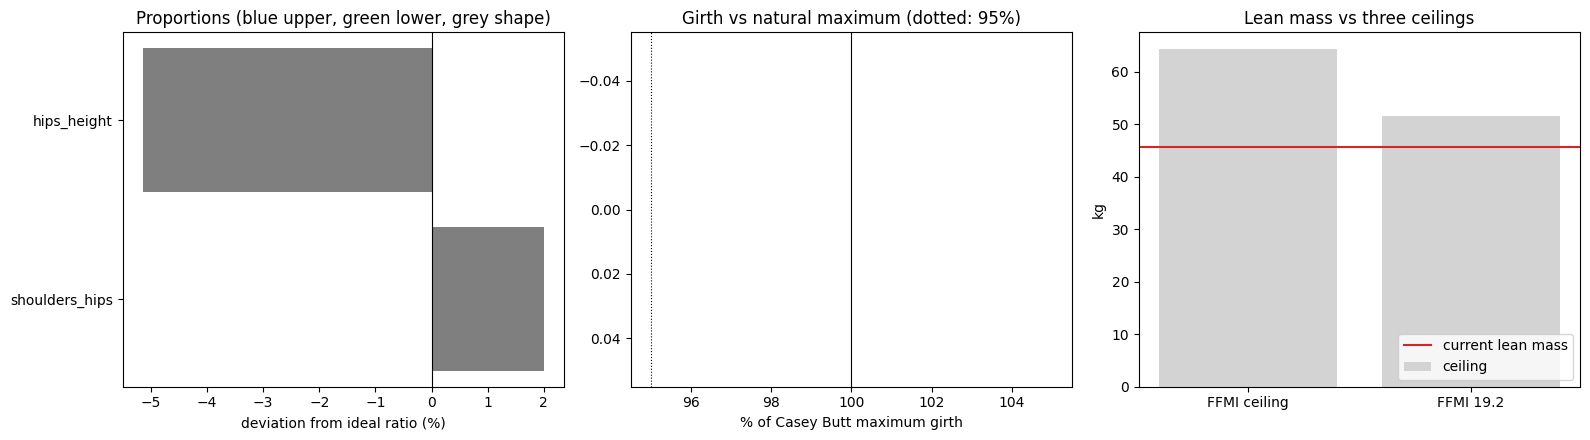

In [5]:
colors = {"upper": "tab:blue", "lower": "tab:green", "shape": "tab:gray"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
a = A.dropna(subset=["deviation"])
ax.barh(a.index, a.deviation * 100, color=[colors[g] for g in a.group])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("deviation from ideal ratio (%)")
ax.set_title("Proportions (blue upper, green lower, grey shape)")
ax.invert_yaxis()

ax = axes[1]
ax.barh(girth.index, girth.attained * 100, color="tab:orange")
ax.axvline(100, color="k", lw=0.8)
ax.axvline(95, color="k", lw=0.8, ls=":")
ax.set_xlabel("% of Casey Butt maximum girth")
ax.set_title("Girth vs natural maximum (dotted: 95%)")
ax.invert_yaxis()

ax = axes[2]
ax.bar(lean.index, lean["max lean (kg)"], color="lightgray", label="ceiling")
ax.axhline(H["Lean mass (kg)"], color="tab:red", label="current lean mass")
ax.set_ylabel("kg")
ax.set_title("Lean mass vs three ceilings")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## Strength
Symmetric Strength's published method: Wathan 1RM, each lift converted to a deadlift equivalent via lift ratios, scored as a quarter of the
age-adjusted Wilks of the total it implies. Ratios are recomputed here from each lift's reference and factor (a second implementation of the workbook's rules).

In [6]:
def ratio_to_deadlift(key, seen=()):
    ref, fac = lifts.at[key, "reference"], float(lifts.at[key, f"factor ({SEX})"])
    if not isinstance(ref, str) or ref == "":
        return fac
    if ref in seen:
        raise ValueError(f"Circular reference at {key}")
    return fac * ratio_to_deadlift(ref, seen + (key,))

def tier(score):
    if score is None or math.isnan(score):
        return ""
    return tiers.loc[tiers["min score"].astype(float) <= score, "tier"].iloc[-1]

def wathan_factor(reps):
    return (P["wathan_a"] + P["wathan_b"] * math.exp(-P["wathan_k"] * reps)) / 100

def cls(dev):
    return "strong" if dev > P["dev_tol"] else ("weak" if dev < -P["dev_tol"] else "in line")

_warned = set()
def strength(raw):
    bw, age = raw["weight"], raw["age"]
    x = bw
    wilks = 500 / (P["wilks_a"] + P["wilks_b"]*x + P["wilks_c"]*x**2 + P["wilks_d"]*x**3 + P["wilks_e"]*x**4 + P["wilks_f"]*x**5)
    agec = float(agecoef.loc[min(90, max(14, int(age)))])
    plsum = 1 + ratio_to_deadlift("squat") + ratio_to_deadlift("bench")
    perkg = plsum * wilks / 4 * agec
    rows = []
    for k in lifts.index:
        load, reps = raw.get(k + "_load"), raw.get(k + "_reps")
        if load is None or reps is None or math.isnan(load) or math.isnan(reps):
            continue
        reps = math.floor(reps)                    # sets to failure; decimals rounded down
        if reps < 1 or reps > 10:
            continue                               # outside Wathan's reliable range: not scored
        bwlift = int(lifts.at[k, "bodyweight lift"]) == 1
        total = load + (bw if bwlift else 0)
        e1 = total / wathan_factor(reps)
        ref = lifts.at[k, "reference"]
        ref_ratio = ratio_to_deadlift(ref) if isinstance(ref, str) and ref else 1.0
        offset = float(lifts.at[k, "bw offset"]) if not pd.isna(lifts.at[k, "bw offset"]) else 0.0
        dleq = (e1 / float(lifts.at[k, f"factor ({SEX})"]) - offset * bw) / ref_ratio
        if dleq <= 0:
            if k not in _warned:
                print(f"{lifts.at[k, 'label']}: below the conversion's range, not scored")
                _warned.add(k)
            continue
        eff = reps
        rows.append({"lift": k, "category": lifts.at[k, "category"], "reps": reps, "total load": total,
                     "e1RM": e1, "e1RM as entered": e1 - (bw if bwlift else 0), "deadlift equiv": dleq,
                     "score": dleq * perkg, "reps maxes": [total * wathan_factor(n) / wathan_factor(eff) - (bw if bwlift else 0) for n in range(1, 11)]})
    T = pd.DataFrame(rows).set_index("lift")
    # machine lifts count for a category only when no free-weight lift is entered in it
    T["equipment"] = [lifts.at[k, "equipment"] for k in T.index]
    free_cats = set(T.loc[T.equipment != "machine", "category"])
    T["eligible"] = [(e != "machine") or (c not in free_cats) for e, c in zip(T.equipment, T.category)]
    E_ = T[T.eligible]
    cats = E_.loc[E_.groupby("category")["score"].idxmax()].reset_index().set_index("category")
    cats = cats.reindex([c for c in ["squat", "floor pull", "horizontal press", "vertical press", "pull"] if c in cats.index])
    overall = cats.score.mean()
    gm = math.exp(np.log(cats.score).mean())
    T["tier"] = T.score.map(tier); T["vs overall"] = T.score / overall - 1; T["class"] = T["vs overall"].map(cls)
    cats["tier"] = cats.score.map(tier); cats["vs overall"] = cats.score / overall - 1; cats["class"] = cats["vs overall"].map(cls)
    pl = {"squat": cats.at["squat", "deadlift equiv"] * ratio_to_deadlift("squat") if "squat" in cats.index else np.nan,
          "bench": cats.at["horizontal press", "deadlift equiv"] * ratio_to_deadlift("bench") if "horizontal press" in cats.index else np.nan,
          "deadlift": cats.at["floor pull", "deadlift equiv"] if "floor pull" in cats.index else np.nan}
    pl_total = np.nansum(list(pl.values()))
    grows = {}
    for g in GROUP_COLS:
        members = [k for k in T.index if lifts.at[k, g] == 1]
        if not members:
            grows[g] = {"score": np.nan, "lifts counted": 0, "lowest lift": np.nan, "highest lift": np.nan, "class": "no data"}
            continue
        d = T.loc[members, "vs overall"]
        lo, hi = d.min(), d.max()
        c = ("strong" if lo > P["dev_tol"] else "weak" if hi < -P["dev_tol"]
             else "in line" if (lo >= -P["dev_tol"] and hi <= P["dev_tol"]) else "mixed")
        grows[g] = {"score": T.loc[members, "score"].mean(), "lifts counted": len(members), "lowest lift": lo, "highest lift": hi, "class": c}
    G = pd.DataFrame(grows).T
    G["score"] = G["score"].astype(float)
    G["tier"] = G.score.map(tier); G["vs overall"] = G.score / overall - 1
    summary = {"Overall (arithmetic)": overall, "Overall tier": tier(overall), "Geometric mean": gm,
               "Strength balance": 100 * gm / overall, "Strongest lift": lifts.at[T.score.idxmax(), "label"],
               "Weakest lift": lifts.at[T.score.idxmin(), "label"], "PL total (kg)": pl_total,
               "Wilks": pl_total * wilks, "Wilks, age-adjusted": pl_total * wilks * agec,
               "Strongest group": G.score.idxmax(), "Weakest group": G.score.idxmin(),
               "Age coefficient": agec, "Wilks coefficient": wilks}
    return T, cats, G, summary, pl

raw = history[date].to_dict()
T, cats, G, S_sum, PLs = strength(raw)
display(T.drop(columns="reps maxes").round(2))
display(cats[["lift", "score", "tier", "vs overall", "deadlift equiv"]].round(2))
display(pd.Series(S_sum).to_frame("value"))
display(pd.DataFrame(T["reps maxes"].tolist(), index=T.index, columns=[f"{n}RM" for n in range(1, 11)]).round(1))
ranked = G.dropna(subset=["score"]).sort_values("vs overall", ascending=False)
print("Muscle groups ranked, strongest first (class: strong / weak only when every contributing lift agrees)")
display(ranked[["vs overall", "class", "lowest lift", "highest lift", "lifts counted"]])
for c_ in ("strong", "weak", "mixed", "in line"):
    print(f"{c_:>8}: {', '.join(ranked.index[ranked['class'] == c_]) or '-'}")


,category,reps,total load,e1RM,e1RM as entered,deadlift equiv,score,equipment,eligible,tier,vs overall,class
lift,,,,,,,,,,,,
squat,squat,5,50.0,58.29,58.29,69.39,43.37,free weight,True,Untrained,-0.11,weak
leg_press,squat,10,120.0,161.70,161.70,58.93,36.83,machine,False,Untrained,-0.24,weak
deadlift,floor pull,5,70.0,81.61,81.61,81.61,51.01,free weight,True,Novice,0.05,in line
bench,horizontal press,5,32.5,37.89,37.89,66.47,41.55,free weight,True,Untrained,-0.15,weak
ohp,vertical press,5,25.0,29.15,29.15,87.52,54.70,free weight,True,Novice,0.12,strong
chin_up,pull,5,36.0,41.97,-24.03,84.40,52.75,free weight,True,Novice,0.08,in line


,lift,score,tier,vs overall,deadlift equiv
category,,,,,
squat,squat,43.37,Untrained,-0.11,69.39
floor pull,deadlift,51.01,Novice,0.05,81.61
horizontal press,bench,41.55,Untrained,-0.15,66.47
vertical press,ohp,54.70,Novice,0.12,87.52
pull,chin_up,52.75,Novice,0.08,84.40


,value
Overall (arithmetic),48.67608
Overall tier,Novice
Geometric mean,48.386556
Strength balance,99.405203
Strongest lift,Overhead press
Weakest lift,45-degree sled leg press
PL total (kg),177.788321
Wilks,184.432985
"Wilks, age-adjusted",184.432985
Strongest group,Lateral delts


,1RM,2RM,3RM,4RM,5RM,6RM,7RM,8RM,9RM,10RM
lift,,,,,,,,,,
squat,57.5,55.4,53.5,51.7,50.0,48.4,47.0,45.7,44.4,43.3
leg_press,159.6,153.8,148.4,143.4,138.7,134.4,130.4,126.7,123.2,120.0
deadlift,80.6,77.6,74.9,72.4,70.0,67.8,65.8,63.9,62.2,60.6
bench,37.4,36.0,34.8,33.6,32.5,31.5,30.5,29.7,28.9,28.1
ohp,28.8,27.7,26.7,25.8,25.0,24.2,23.5,22.8,22.2,21.6
chin_up,-24.6,-26.1,-27.5,-28.8,-30.0,-31.1,-32.2,-33.1,-34.0,-34.9


Muscle groups ranked, strongest first (class: strong / weak only when every contributing lift agrees)


,vs overall,class,lowest lift,highest lift,lifts counted
Lateral delts,0.123844,strong,0.123844,0.123844,1
Posterior delts,0.083707,in line,0.083707,0.083707,1
Biceps,0.083707,in line,0.083707,0.083707,1
Lats,0.083707,in line,0.083707,0.083707,1
Obliques & serratus,0.065789,in line,0.047872,0.083707,2
Upper traps,0.047872,in line,0.047872,0.047872,1
Middle traps,0.047872,in line,0.047872,0.047872,1
Forearms,0.047872,in line,0.047872,0.047872,1
Abdominals,0.007542,mixed,-0.108952,0.083707,3
Anterior delts,-0.011313,mixed,-0.14647,0.123844,2


  strong: Lateral delts
    weak: Hip flexors, Pecs, Hip adductors
   mixed: Abdominals, Anterior delts, Triceps, Spinal erectors, Hamstrings, Glutes, Quads
 in line: Posterior delts, Biceps, Lats, Obliques & serratus, Upper traps, Middle traps, Forearms


Anchor check: 310 lb deadlift at 180 lb scores 76.7 (expected about 60)


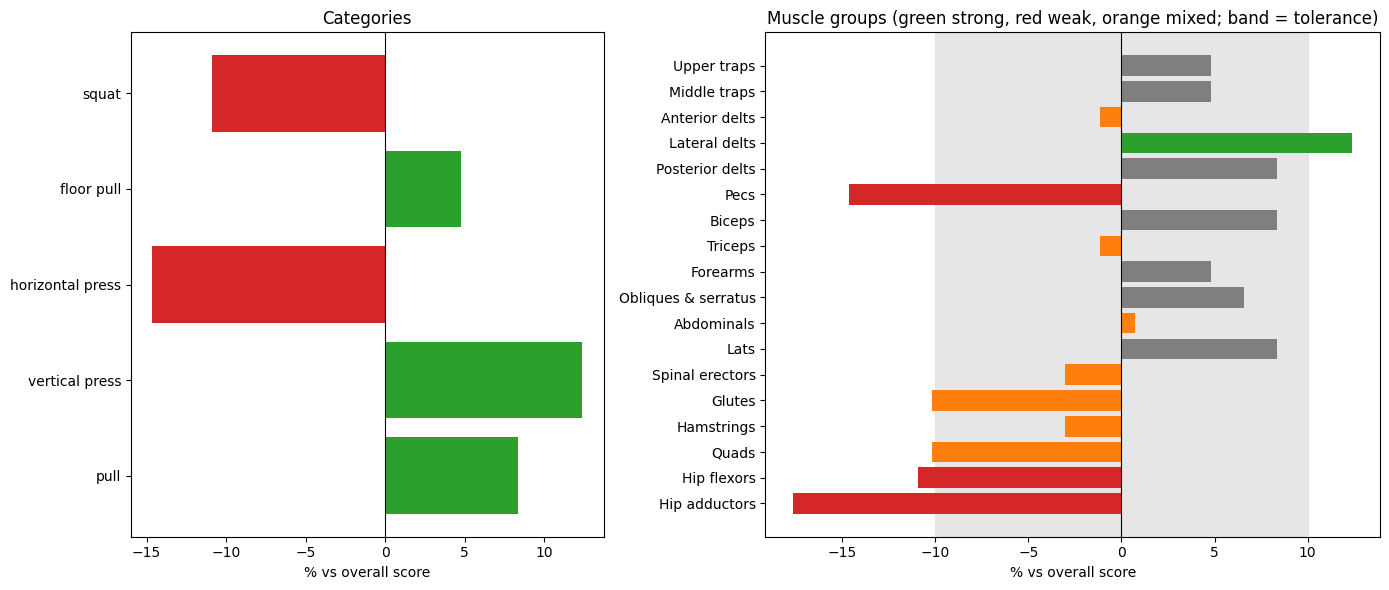

In [7]:
# Symmetric Strength anchor check: its published intermediate standard for a 180 lb (81.65 kg) man under 40
# is a 310 lb (140.6 kg) deadlift, which should score about 60 (the Intermediate threshold).
bw = 81.65
w = 500 / (P["wilks_a"] + P["wilks_b"]*bw + P["wilks_c"]*bw**2 + P["wilks_d"]*bw**3 + P["wilks_e"]*bw**4 + P["wilks_f"]*bw**5)
print(f"Anchor check: 310 lb deadlift at 180 lb scores {140.61 * (1 + ratio_to_deadlift('squat') + ratio_to_deadlift('bench')) * w / 4:.1f} (expected about 60)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
ax.barh(cats.index, cats["vs overall"] * 100, color=["tab:green" if v >= 0 else "tab:red" for v in cats["vs overall"]])
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis(); ax.set_xlabel("% vs overall score"); ax.set_title("Categories")
g = G.dropna(subset=["score"])
ax = axes[1]
palette = {"strong": "tab:green", "weak": "tab:red", "mixed": "tab:orange", "in line": "tab:gray"}
ax.barh(g.index, g["vs overall"].astype(float) * 100, color=[palette[c] for c in g["class"]])
ax.axvspan(-100 * P["dev_tol"], 100 * P["dev_tol"], color="0.9", zorder=0)
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis(); ax.set_xlabel("% vs overall score")
ax.set_title("Muscle groups (green strong, red weak, orange mixed; band = tolerance)")
plt.tight_layout(); plt.show()


## Composite: health, strength, size, aesthetics
Five attributes, each measured once (leanness, fitness, strength, size, proportion), on 0-1 scales, combined by a weighted
geometric mean with the weights set on the Summary sheet. An attribute without data (e.g. no fitness test yet) is left out.

Weights from: purposes
Coverage: 100%


,VO2max,norms,percentile,90th percentile,score
test,,,,,
Rockport walk,31.150208,treadmill,60.577724,42.1,0.73991


,score,weight,share
Leanness,0.911,0.222,0.222
Fitness,0.740,0.278,0.278
Strength,0.484,0.278,0.278
Size,0.712,0.111,0.111
Proportion,0.961,0.111,0.111


Composite: 0.706   weakest: Strength

Purpose scores (equal-weight geometric mean of each purpose's attributes)
  health       score 0.688
  looks        score 0.854
  performance  score 0.598


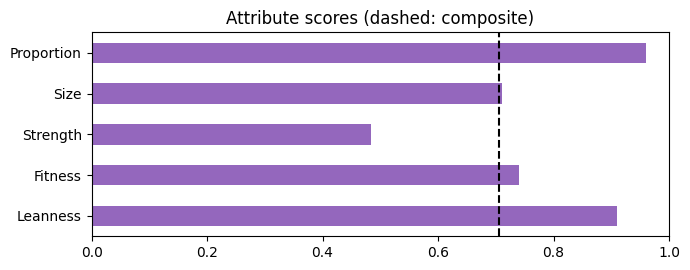

In [8]:
# Weights: Summary!B3 picks the Attributes sheet or the Purposes sheet (rank -> 1/rank, or points, which override ranks)
summ = pd.read_excel(WORKBOOK, sheet_name="Summary", header=None, engine=engine)
aws = pd.read_excel(WORKBOOK, sheet_name="Attributes", header=None, engine=engine)
h0 = aws.index[aws[0] == "attribute"][0]
hdr = list(aws.loc[h0])
wtab = aws.loc[h0 + 1:h0 + 5, [0, hdr.index("rank"), hdr.index("points")]]
wtab.columns = ["attribute", "rank", "points"]
wtab = wtab.set_index("attribute").apply(pd.to_numeric, errors="coerce")
if wtab["points"].fillna(0).sum() > 0:
    base_weights = wtab["points"].fillna(0).to_dict()
else:
    base_weights = (1 / wtab["rank"]).fillna(0).to_dict()
mode = str(summ.at[summ.index[summ[0] == "Weights from"][0], 1]).strip()
pur = block("attribute", "health").set_index("attribute")
PURPOSES = ["health", "looks", "performance"]
pws = pd.read_excel(WORKBOOK, sheet_name="Purposes", header=None, engine=engine)
ph = pws.index[pws[0] == "purpose"][0]
ptab = pws.loc[ph + 1:ph + 3, [0, 1, 2]]
ptab.columns = ["purpose", "rank", "points"]
ptab["purpose"] = ptab["purpose"].str.lower().str.split().str[0]   # "Health (fitness-related)" -> "health"
ptab = ptab.set_index("purpose").apply(pd.to_numeric, errors="coerce")
purpose_base = (ptab["points"].fillna(0) if ptab["points"].fillna(0).sum() > 0 else (1 / ptab["rank"]).fillna(0)).to_dict()

def attribute_weights(avail):
    """Weights actually used, given which attributes have data."""
    if mode != "purposes":
        return {a: base_weights[a] for a in avail}
    served = {p: [a for a in avail if float(pur.at[a, p]) == 1] for p in PURPOSES}
    pw = {p: purpose_base[p] for p in PURPOSES if served[p]}
    tot = sum(pw.values())
    return {a: sum(pw[p] / tot / len(served[p]) for p in pw if a in served[p]) for a in avail}
print(f"Weights from: {mode}")

# Fitness: VO2max estimates from the tests entered, FRIEND percentiles
friend = block("key", "sex|mode").set_index("key")
DEC = ["p10", "p20", "p30", "p40", "p50", "p60", "p70", "p80", "p90"]
def friend_row(mode, age):
    return friend.loc[f"{SEX}|{mode}|{min(80, max(20, int(age // 10) * 10))}", DEC].astype(float).values
def p90_of(mode, age):
    return friend_row(mode, age)[8]
def percentile(v, mode, age):
    """Interpolated only within FRIEND's published 10th-90th range; no extrapolation."""
    row = friend_row(mode, age)
    if v < row[0]:
        return "below 10th"
    if v > row[8]:
        return "above 90th"
    k = 1
    for i in range(9):
        if v >= row[i]:
            k = i + 1
    k = min(k, 8)
    return 10 * (k + (v - row[k - 1]) / (row[k] - row[k - 1]))

def fitness(raw, vo2_shift=0.0):
    g = lambda k: raw.get(k) if raw.get(k) is not None and not math.isnan(raw.get(k)) else None
    w, age = raw["weight"], raw["age"]
    est = []
    t, hr = g("rockport_time"), g("rockport_hr")
    if t is not None and hr is not None:
        est.append(("Rockport walk", P["rock_a"] - P["rock_b"] * w / P["kg_per_lb"] - P["rock_c"] * age + P["rock_d"]
                    - P["rock_e"] * t - P["rock_f"] * hr, "treadmill"))
    d = g("cooper_distance")
    if d is not None:
        est.append(("Cooper run", (d - P["cooper_a"]) / P["cooper_b"], "treadmill"))
    W = g("cycle_watts")
    if W is not None:
        est.append(("Cycle ramp (ACSM)", P["cyc_a"] * W / w + P["cyc_b"], "cycle"))
    rows = []
    for n_, v, md in est:
        v = v + vo2_shift
        p90 = p90_of(md, age)
        rows.append((n_, v, md, percentile(v, md, age), p90, v / p90))
    return pd.DataFrame(rows, columns=["test", "VO2max", "norms", "percentile", "90th percentile", "score"]).set_index("test")

def evaluate(raw, vo2_shift=0.0):
    """Whole model on one set of raw measurements -> (composite, dimension scores, pieces)."""
    m_ = with_means(raw)
    H_ = health(m_)
    A_, As_ = aesthetics(m_)
    lean_, girth_ = potential(m_, H_["Lean mass (kg)"])
    T_, cats_, G_, S_, _ = strength(raw)
    whtr = m_["waist"] / m_["height"]
    F_ = fitness(raw, vo2_shift)
    d = {
        "Leanness": max(0.0, min(1.0, (P["whtr_zero"] - whtr) / (P["whtr_zero"] - P["whtr_best"]))),
        "Fitness": float(F_.score.median()) if len(F_) else float("nan"),
        "Strength": S_["Geometric mean"] / P["strength_ref"],
        "Size": H_["Lean mass (kg)"] / primary_ceiling(lean_),
        "Proportion": 1 / (1 + As_["Overall distance (RMS log, as %)"]),   # nan if no ratio applies
    }
    avail = {k: v for k, v in d.items() if not math.isnan(v)}
    wts = attribute_weights(avail)
    comp = 0.0 if min(avail.values()) <= 0 else math.exp(sum(wts[k] * math.log(v) for k, v in avail.items()) / sum(wts.values()))
    return comp, d, dict(A=A_, girth=girth_, cats=cats_, G=G_, F=F_)

composite, dims, pieces = evaluate(raw)
_w = attribute_weights({k for k, v in dims.items() if not math.isnan(v)})
weights = {k: _w.get(k, 0.0) for k in dims}
_full = attribute_weights(set(dims))                      # intended weights if everything were measured
coverage = sum(v for k, v in _full.items() if not math.isnan(dims[k])) / sum(_full.values())
print(f"Coverage: {coverage:.0%}" + ("" if coverage > 0.9999 else "  PROVISIONAL: a weighted attribute has no data"))
if len(pieces["F"]):
    display(pieces["F"])
else:
    print("No fitness test entered for this date: fitness is left out of the composite.")
C = pd.DataFrame({"score": dims, "weight": weights})
C["share"] = C.weight / C.weight.sum()
display(C.round(3))
avail_dims = {k: v for k, v in dims.items() if not math.isnan(v)}
print(f"Composite: {composite:.3f}   weakest: {min(avail_dims, key=avail_dims.get)}")
# Purposes view (read-only)
share = C["share"]
print("\nPurpose scores (equal-weight geometric mean of each purpose's attributes)")
purpose_scores = {}
for p_ in PURPOSES:
    xs = [math.log(dims[a]) for a in dims if not math.isnan(dims[a]) and float(pur.at[a, p_]) == 1]
    purpose_scores[p_] = math.exp(sum(xs) / len(xs)) if xs else float("nan")
    print(f"  {p_:12s} score {purpose_scores[p_]:.3f}")
ax = C.score.plot.barh(xlim=(0, 1), color="tab:purple", figsize=(7, 2.8)); ax.axvline(composite, color="k", ls="--")
ax.set_title("Attribute scores (dashed: composite)"); plt.tight_layout(); plt.show()


## Levers: what moves the composite most
Each lever is applied to your real measurements and the whole model is re-run. "Per week" multiplies by the rough weekly rates on
Parameters, which are guesses; the per-unit column is exact for the model. Re-run after each new assessment: the ranking shifts as you change.

In [9]:
rates = block("lever", "per week").set_index("lever")["per week"].astype(float)

def lever_effect(apply):
    r2 = dict(raw)
    apply(r2)
    return evaluate(r2)[0] / composite - 1

def fat_loss(r2):
    r2["waist"] -= 1; r2["weight"] -= 1
def lean_gain(r2):
    r2["weight"] += 1
def girth_lever(site):
    def f(r2):   # growth shows in both the flexed (proportion) and relaxed (Butt) girths where both exist
        for key in (site, site + "_relaxed"):
            if key + "_l" in r2:
                r2[key + "_l"] += 1; r2[key + "_r"] += 1
            elif key in r2:
                r2[key] += 1
    return f
def lift(k):
    def f(r2):
        bw = r2["weight"] if int(lifts.at[k, "bodyweight lift"]) == 1 else 0
        r2[k + "_load"] = (r2[k + "_load"] + bw) * 1.01 - bw
    return f

rows = [("Waist -1 cm with weight -1 kg (fat loss)", "fat_loss", fat_loss),
        ("Bodyweight +1 kg at the same waist", "lean_gain", lean_gain)]
for k in lifts.index:
    v = raw.get(k + "_load")
    if v is not None and not math.isnan(v):
        rows.append((f"{lifts.at[k, 'label']} +1% 1RM", "lift", lift(k)))
for site in (["arm", "forearm", "chest", "shoulders", "thigh", "calf"] if SEX == "male" else ["shoulders", "hips"]):
    rows.append((f"{site.capitalize()} +1 cm", site, girth_lever(site)))
out = []
for label, key, fn in rows:
    g = lever_effect(fn)
    out.append((label, 100 * g, rates[key], 100 * g * rates[key]))
if len(pieces["F"]):
    g = evaluate(raw, vo2_shift=1.0)[0] / composite - 1
    out.append(("VO2max +1 ml/kg/min", 100 * g, rates["fitness"], 100 * g * rates["fitness"]))
else:
    print("Fitness lever not shown: no fitness test entered.")
Lv = pd.DataFrame(out, columns=["lever", "composite % per unit", "units per week (rough)", "composite % per week"]).set_index("lever")
display(Lv.sort_values("composite % per week", ascending=False).round(3))


,composite % per unit,units per week (rough),composite % per week
lever,,,
Waist -1 cm with weight -1 kg (fat loss),1.193,0.50,0.597
VO2max +1 ml/kg/min,0.882,0.30,0.264
Back squat +1% 1RM,0.055,2.00,0.111
Chin-up +1% 1RM,0.055,2.00,0.111
Deadlift +1% 1RM,0.055,2.00,0.111
Overhead press +1% 1RM,0.055,2.00,0.111
Bench press +1% 1RM,0.055,2.00,0.111
Hips +1 cm,0.018,0.10,0.002
45-degree sled leg press +1% 1RM,0.000,2.00,0.000


## Plan tiers
Same rules as the Plan sheet, recomputed here and checked against it.

In [10]:
def tier_of_class(c):
    return {"weak": "hard", "strong": "maintenance", "no data": ""}.get(c, "medium")
TN = {"": 0, "maintenance": 1, "medium": 2, "hard": 3}
NT = {v: k for k, v in TN.items()}

cat_tier = {c: tier_of_class(cats.at[c, "class"]) for c in cats.index}
A_dev = A["deviation"]
g_att = girth["attained"]
imp = ratios.set_index("key")["ideal"].astype(float)
SITE_KEYS = {"male": {"arm": "arm_wrist", "forearm": "forearm_wrist", "chest": "chest_wrist", "shoulders": "shoulders_chest",
                      "thigh": "thigh_knee", "calf": "calf_ankle", "neck": "neck_arm"},
             "female": {"shoulders": "shoulders_hips", "hips": "hips_height"}}[SEX]
ALL_SITES = ["arm", "forearm", "chest", "shoulders", "thigh", "calf", "neck", "hips"]
def size_tier(site):
    dv = A_dev.get(SITE_KEYS[site], np.nan) if site in SITE_KEYS else np.nan
    at = g_att.get(site, np.nan)
    ok_d, ok_a = not pd.isna(dv), not pd.isna(at)
    if not ok_d and not ok_a:
        return ""
    if (ok_d and dv < P["size_hard_dev"]) or (ok_a and at < P["size_hard_att"]):
        return "hard"
    if (ok_d and dv < P["size_med_dev"]) or (ok_a and at < P["size_med_att"]):
        return "medium"
    return "maintenance"
site_tier = {s: size_tier(s) for s in ALL_SITES}
GROUP_SITE = ({"Biceps": "arm", "Triceps": "arm", "Forearms": "forearm", "Pecs": "chest", "Anterior delts": "shoulders",
               "Lateral delts": "shoulders", "Posterior delts": "shoulders", "Quads": "thigh", "Hamstrings": "thigh",
               "Glutes": "thigh", "Hip adductors": "thigh", "Calves": "calf"} if SEX == "male" else
              {"Anterior delts": "shoulders", "Lateral delts": "shoulders", "Posterior delts": "shoulders",
               "Glutes": "hips", "Hip adductors": "hips"})
grp = pd.DataFrame(index=GROUP_COLS)
grp["strength tier"] = [tier_of_class(G.at[g, "class"]) for g in GROUP_COLS]
grp["size tier"] = [site_tier[GROUP_SITE[g]] if g in GROUP_SITE else "" for g in GROUP_COLS]
grp["tier"] = [NT[max(TN[a], TN[b])] or "no data" for a, b in zip(grp["strength tier"], grp["size tier"])]
display(grp)

lib = block("exercise", "type").set_index("exercise")
def ex_priority(ex):
    size_t = grp["size tier"].get(lib.at[ex, "primary group"], "")
    if str(lib.at[ex, "type"]).startswith("compound"):
        return NT[max(TN[cat_tier.get(lib.at[ex, "pattern"], "")], TN[size_t])]
    return NT[max(1, TN[size_t])]
ex = pd.DataFrame({"type": lib["type"], "priority": [ex_priority(e) for e in lib.index],
                   "trains": [", ".join(g for g in GROUP_COLS if lib.at[e, g] == 1) for e in lib.index]})
ex["_k"] = ex.priority.map(TN) * 10 + ex.type.str.startswith("compound")
ex = ex.sort_values("_k", ascending=False, kind="stable").drop(columns="_k")
for t_ in ("hard", "medium", "maintenance"):
    print(f"\n{t_.upper()}")
    for e, row in ex[ex.priority == t_].iterrows():
        print(f"  {e:30s} {row.type:18s} {row.trains}")

# check against the workbook's Plan sheet
plan = pd.read_excel(WORKBOOK, sheet_name="Plan", header=None, engine=engine)
wb_vals = {}
for i in plan.index:
    k = plan.at[i, 0]
    if k in cat_tier: wb_vals[("category", k)] = plan.at[i, 4]
    elif k in site_tier: wb_vals[("site", k)] = plan.at[i, 3]
    elif k in grp.index: wb_vals[("group", k)] = plan.at[i, 5]
    elif k in ex.index: wb_vals[("exercise", k)] = plan.at[i, 2]
mine = {**{("category", k): v for k, v in cat_tier.items()}, **{("site", k): v for k, v in site_tier.items()},
        **{("group", k): v for k, v in grp["tier"].items()}, **{("exercise", k): v for k, v in ex["priority"].items()}}
norm = lambda x: "" if x is None or (isinstance(x, float) and math.isnan(x)) else x
diff = {k: (v, wb_vals.get(k)) for k, v in mine.items() if norm(v) != norm(wb_vals.get(k))}
print("\nPlan tiers agree with the workbook." if not diff else f"\nPlan tiers differ: {diff}")


,strength tier,size tier,tier
Upper traps,medium,,medium
Middle traps,medium,,medium
Lower traps,,,no data
Anterior delts,medium,maintenance,medium
Lateral delts,maintenance,maintenance,maintenance
Posterior delts,medium,maintenance,medium
Pecs,hard,,hard
Biceps,medium,,medium
Triceps,medium,,medium
Forearms,medium,,medium



HARD
  Back squat                     compound (major)   Spinal erectors, Glutes, Quads, Hip adductors
  Front squat                    compound (major)   Abdominals, Glutes, Quads
  Leg press                      compound (major)   Glutes, Quads, Hip adductors
  Bulgarian split squat          compound (major)   Glutes, Quads, Hip adductors
  Bench press                    compound (major)   Anterior delts, Pecs, Triceps
  Incline bench press            compound (major)   Anterior delts, Pecs, Triceps
  Dumbbell bench press           compound (major)   Anterior delts, Pecs, Triceps
  Close-grip bench press         compound (major)   Pecs, Triceps
  Dip                            compound (major)   Anterior delts, Pecs, Triceps

MEDIUM
  Deadlift                       compound (major)   Upper traps, Forearms, Spinal erectors, Glutes, Hamstrings
  Romanian deadlift              compound (major)   Spinal erectors, Glutes, Hamstrings
  Hip thrust                     compound (major)   Glu

In [11]:
# History: only meaningful once there are two or more dated columns
if history.shape[1] < 2:
    print("Only one dated column; no history to plot yet.")
else:
    rows = {}
    for d in history.columns:
        try:
            _, h, _, s, _, _, _ = assess(d)
            rows[d] = {"weight": history.at["weight", d], "body fat %": 100 * h["Body fat (US Navy)"],
                       "lean mass": h["Lean mass (kg)"], "aesthetic distance %": 100 * s["Overall distance (RMS log, as %)"]}
        except (KeyError, ValueError, TypeError):
            pass  # a date lacking the core inputs is skipped, not guessed
    hist = pd.DataFrame(rows).T
    display(hist.round(1))
    hist.plot(subplots=True, marker="o", figsize=(10, 7), legend=True); plt.tight_layout(); plt.show()


Only one dated column; no history to plot yet.


## Cross-check against the workbook
Compares this notebook's numbers with the cached values in the workbook's *Report* sheet.
Cached values exist once the workbook has been saved by Excel or LibreOffice. The check is only
meaningful when both analyse the same date.

In [12]:
rep = pd.read_excel(WORKBOOK, sheet_name="Report", header=None, engine=engine)
lookup = {str(k): v for k, v in zip(rep[0], rep[1]) if isinstance(k, str)}
rep_date = pd.to_datetime(lookup.get("Analysis date"))
checks = {
    "Body fat (US Navy tape method)": H["Body fat (US Navy)"],
    "Lean mass (kg)": H["Lean mass (kg)"],
    "FFMI, height-normalised (men)": H["FFMI, height-normalised"],
    "Overall distance from ideal (RMS of log deviations, as %)": A_sum["Overall distance (RMS log, as %)"],
    "Upper vs lower balance": A_sum["Upper vs lower balance"],
    "Upper reference used for the size score": primary_ceiling(lean),
}
ratio_rows = {str(k): v for k, v in zip(rep[0], rep[2]) if str(k) in A.index}
stw = pd.read_excel(WORKBOOK, sheet_name="Strength", header=None, engine=engine)
smw = pd.read_excel(WORKBOOK, sheet_name="Summary", header=None, engine=engine)
lookup.update({f"strength: {k}": v for k, v in zip(stw[0], stw[1]) if isinstance(k, str)})
lookup.update({f"summary: {k}": v for k, v in zip(smw[0], smw[1]) if isinstance(k, str)})
checks.update({
    "strength: Overall strength score (arithmetic, as Symmetric Strength)": S_sum["Overall (arithmetic)"],
    "strength: Geometric-mean strength score (used in the composite)": S_sum["Geometric mean"],
    "strength: Strength balance (100 = perfectly even; = 100 x geometric / arithmetic)": S_sum["Strength balance"],
    "strength: Total (kg)": S_sum["PL total (kg)"],
    "strength: Wilks": S_sum["Wilks"],
    "summary: Leanness": dims["Leanness"], "summary: Fitness": dims["Fitness"], "summary: Strength": dims["Strength"],
    "summary: Size": dims["Size"], "summary: Proportion": dims["Proportion"], "summary: Composite in use": composite,
    "summary: Coverage (share of your weight that is measured)": coverage,
})
hdr = stw.index[stw[0] == "lift"][0]
score_col = list(stw.loc[hdr]).index("score")
for k in T.index:
    lab = lifts.at[k, "label"]
    row = stw.index[stw[0] == lab]
    if len(row):
        lookup[f"strength: score {lab}"] = stw.at[row[0], score_col]
        checks[f"strength: score {lab}"] = T.at[k, "score"]
checks.update({f"ratio {k}": A.at[k, "actual"] for k in ratio_rows})

if pd.isna(rep_date) or rep_date.normalize() != date.normalize():
    print(f"Workbook analyses {rep_date}, notebook analyses {date.date()}: not comparable.")
else:
    out = []
    for label, mine in checks.items():
        theirs = ratio_rows.get(label[6:]) if label.startswith("ratio ") else lookup.get(label)
        blank = theirs is None or theirs == "" or (isinstance(theirs, float) and math.isnan(theirs))
        if blank and math.isnan(mine):
            out.append((label, mine, None, "agree (both blank: missing input)"))
        elif blank:
            out.append((label, mine, None, "no cached value"))
        else:
            ok = math.isclose(mine, float(theirs), rel_tol=1e-9, abs_tol=1e-9) if not math.isnan(mine) else False
            out.append((label, mine, float(theirs), "agree" if ok else "DISAGREE"))
    res = pd.DataFrame(out, columns=["quantity", "notebook", "workbook", "status"]).set_index("quantity")
    display(res)
    print("All agree." if res.status.str.startswith("agree").all() else "Check the rows not marked 'agree'.")
    gi = stw.index[stw[0] == "muscle group"]
    wb_cls = {stw.at[i, 0]: stw.at[i, 7] for i in range(gi[0] + 1, gi[0] + 1 + len(GROUP_COLS))} if len(gi) else {}
    diff = {g_: (G.at[g_, "class"], wb_cls.get(g_)) for g_ in GROUP_COLS if G.at[g_, "class"] != wb_cls.get(g_)}
    print("Muscle-group classes agree." if not diff else f"Muscle-group classes differ: {diff}")


,notebook,workbook,status
quantity,,,
Body fat (US Navy tape method),0.306958,0.306958,agree
Lean mass (kg),45.740773,45.740773,agree
"FFMI, height-normalised (men)",NaN,NaN,agree (both blank: missing input)
"Overall distance from ideal (RMS of log deviations, as %)",0.040724,0.040724,agree
Upper vs lower balance,NaN,NaN,agree (both blank: missing input)
Upper reference used for the size score,64.281440,64.281440,agree
"strength: Overall strength score (arithmetic, as Symmetric Strength)",48.676080,48.676080,agree
strength: Geometric-mean strength score (used in the composite),48.386556,48.386556,agree
strength: Strength balance (100 = perfectly even; = 100 x geometric / arithmetic),99.405203,99.405203,agree


All agree.
Muscle-group classes agree.
